#### =============================================================
### E-COMMERCE SALES & CUSTOMER BEHAVIOR ANALYTICS
### Dataset: E-commerce Transactions + Clickstream Dataset
#### =============================================================

#### ===================================
### 1. IMPORT LIBRARIES
#### ===================================

In [927]:
import pandas as pd
import numpy as np

#### ===================================
### 2. LOAD DATASETS
#### ===================================

In [1168]:
customers = pd.read_csv("customers.csv")
orders = pd.read_csv("orders.csv")
order_items = pd.read_csv("order_items.csv")
products = pd.read_csv("products.csv")
reviews = pd.read_csv("reviews.csv")
sessions = pd.read_csv("sessions.csv")
events = pd.read_csv("events.csv")


### 2.1 Preview the First 10 Records of Each Table

In [1169]:
customers.head(10)

,customer_id,name,email,country,age,signup_date,marketing_opt_in
0,1,Jennifer Salinas,nicholas59@example.org,JP,71,9/4/2020,True
1,2,Phillip Ramos,christinarubio@example.com,IN,26,4/5/2020,False
2,3,Dawn Fowler,jessica03@example.org,BR,21,8/31/2023,True
3,4,Mario Butler,paula27@example.org,FR,63,6/30/2022,True
4,5,Amber Brown,kevin85@example.net,BR,19,7/22/2022,True
5,6,Kevin Chapman,michaelpoole@example.org,US,28,10/21/2020,False
6,7,Timothy Sanchez,shannonbrown@example.org,IN,48,7/24/2025,False
7,8,Rachael Morales,tammy08@example.com,GB,33,10/9/2022,True
8,9,Laura Guzman,awright@example.org,US,32,7/29/2024,True
9,10,Alexander Lopez,brianmaxwell@example.org,JP,39,1/13/2023,True


In [1172]:
orders.head(10)

,order_id,customer_id,order_time,payment_method,discount_pct,subtotal_usd,total_usd,country,device,source
0,1,13917,2025-01-31T23:07:42,card,20,107.15,85.72,PL,desktop,organic
1,2,1022,2024-02-19T01:17:50,card,0,116.17,116.17,FR,tablet,organic
2,3,6145,2024-12-04T20:24:13,card,0,137.35,137.35,US,mobile,organic
3,4,3152,2024-07-17T08:50:47,card,15,32.18,27.35,BR,mobile,email
4,5,12378,2020-08-21T16:54:16,card,0,238.09,238.09,NL,desktop,paid
5,6,18712,2022-03-07T03:42:34,paypal,0,129.64,129.64,GB,mobile,paid
6,7,17224,2020-03-15T08:56:46,wallet,15,145.45,123.63,JP,mobile,paid
7,8,3448,2021-12-06T01:26:52,card,0,9.03,9.03,JP,desktop,direct
8,9,9132,2022-11-28T03:34:04,card,20,392.95,314.36,IN,mobile,direct
9,10,14764,2023-03-15T10:06:17,paypal,20,9.69,7.75,ES,mobile,organic


In [1174]:
order_items.head(10)

,order_id,product_id,unit_price_usd,quantity,line_total_usd
0,1,226,107.15,1,107.15
1,2,771,116.17,1,116.17
2,3,415,94.49,1,94.49
3,3,24,42.86,1,42.86
4,4,1157,32.18,1,32.18
5,5,846,39.60,1,39.60
6,5,745,198.49,1,198.49
7,6,123,81.79,1,81.79
8,6,888,47.85,1,47.85
9,7,405,5.63,1,5.63


In [1176]:
products.head(10)

,product_id,category,name,price_usd,cost_usd,margin_usd
0,1,Electronics,SSD MediumBlue 149,570.28,352.69,217.59
1,2,Electronics,Keyboard DeepPink 696,498.13,263.13,235.00
2,3,Electronics,Headphones Orchid 188,548.53,309.60,238.93
3,4,Electronics,Smartwatch BurlyWood 664,268.36,153.56,114.80
4,5,Electronics,Smartwatch Cornsilk 328,63.69,42.65,21.04
5,6,Electronics,Headphones WhiteSmoke 326,358.95,222.19,136.76
6,7,Electronics,Headphones DarkGray 529,347.30,187.53,159.77
7,8,Electronics,Mouse Moccasin 673,338.19,227.02,111.17
8,9,Electronics,Mouse Chartreuse 292,88.74,59.58,29.16
9,10,Electronics,SSD Tan 677,85.54,61.04,24.50


In [1178]:
reviews.head(10)

,review_id,order_id,product_id,rating,review_text,review_time
0,1,4,1157,2,Not great quality.,2022-02-01T00:00:00
1,2,7,405,4,Good value for money!,2020-03-07T00:00:00
2,3,7,487,5,"Excellent product, highly recommend!",2024-12-26T00:00:00
3,4,7,442,5,"Excellent product, highly recommend!",2021-03-18T00:00:00
4,5,7,348,4,Good value for money!,2025-09-30T00:00:00
5,6,23,1018,4,Good value for money!,2021-12-11T00:00:00
6,7,33,769,2,Not great quality.,2021-06-04T00:00:00
7,8,36,602,4,Good value for money!,2025-07-10T00:00:00
8,9,36,351,5,"Excellent product, highly recommend!",2020-05-08T00:00:00
9,10,49,501,3,Okay overall.,2023-02-12T00:00:00


In [1180]:
sessions.head(10)

,session_id,customer_id,start_time,device,source,country
0,1,12360,2021-12-27T00:01:36,mobile,email,DE
1,2,13917,2025-01-31T21:29:42,desktop,organic,PL
2,3,1022,2024-02-19T00:52:50,tablet,organic,FR
3,4,2882,2024-08-04T19:54:31,mobile,direct,GB
4,5,1286,2022-06-28T13:58:08,desktop,email,ES
5,6,2319,2020-07-22T20:10:01,mobile,paid,SG
6,7,7050,2023-05-07T14:35:49,mobile,email,GB
7,8,5687,2020-07-10T10:35:54,mobile,email,DE
8,9,6476,2024-02-22T16:57:44,mobile,direct,PL
9,10,6145,2024-12-04T18:53:13,mobile,organic,US


In [1182]:
events.head(10)

,event_id,session_id,timestamp,event_type,product_id,qty,cart_size,payment,discount_pct,amount_usd
0,1,1,2021-12-27T00:08:36,page_view,93.0,NaN,NaN,NaN,NaN,NaN
1,2,1,2021-12-27T00:16:36,page_view,1005.0,NaN,NaN,NaN,NaN,NaN
2,3,1,2021-12-27T00:18:01,add_to_cart,1005.0,1.0,NaN,NaN,NaN,NaN
3,4,1,2021-12-27T00:45:36,page_view,918.0,NaN,NaN,NaN,NaN,NaN
4,5,1,2021-12-27T01:03:36,page_view,946.0,NaN,NaN,NaN,NaN,NaN
5,6,1,2021-12-27T01:05:05,add_to_cart,946.0,1.0,NaN,NaN,NaN,NaN
6,7,1,2021-12-27T01:18:36,page_view,915.0,NaN,NaN,NaN,NaN,NaN
7,8,1,2021-12-27T01:37:36,page_view,931.0,NaN,NaN,NaN,NaN,NaN
8,9,1,2021-12-27T01:39:00,add_to_cart,931.0,1.0,NaN,NaN,NaN,NaN
9,10,1,2021-12-27T01:59:36,page_view,978.0,NaN,NaN,NaN,NaN,NaN


### 2.2 View Random 10 Records

In [1184]:
customers.sample(10)

,customer_id,name,email,country,age,signup_date,marketing_opt_in
17224,17225,Jonathon Kent,joshuacarney@example.net,GB,51,1/21/2021,False
16438,16439,Diane Martin,deckerkatrina@example.com,US,45,4/3/2024,False
2665,2666,Donald Gillespie,gdavis@example.org,ES,44,2/14/2022,False
6593,6594,Hannah Kaufman,scottruiz@example.com,PL,24,9/10/2023,True
7508,7509,Amy Cole,patriciashields@example.org,CA,39,2/2/2024,False
14414,14415,Vanessa Torres,jasonjames@example.org,DE,47,9/24/2025,False
5794,5795,Cynthia Gonzales,greengrant@example.org,GB,53,8/19/2025,True
12487,12488,Henry Sanchez,mark96@example.com,US,27,11/19/2021,True
2735,2736,Rebecca Miller,brian16@example.com,GB,50,4/2/2023,True
13130,13131,Terry Shaw,petersmadeline@example.com,MX,22,8/30/2025,True


In [1186]:
orders.sample(10)

,order_id,customer_id,order_time,payment_method,discount_pct,subtotal_usd,total_usd,country,device,source
32898,32899,12930,2020-11-25T03:11:14,card,15,214.84,182.61,AE,desktop,direct
8339,8340,5631,2023-06-25T19:39:35,card,5,81.79,77.70,PL,desktop,paid
31863,31864,225,2021-12-21T23:07:49,paypal,20,94.20,75.36,AU,mobile,direct
27872,27873,16863,2024-03-22T14:02:49,card,20,711.56,569.25,GB,mobile,email
21647,21648,11165,2021-12-12T00:04:53,card,10,71.16,64.04,ZA,desktop,direct
16310,16311,16531,2020-12-17T14:35:32,paypal,0,216.22,216.22,ES,tablet,direct
12672,12673,1262,2021-02-22T17:21:22,paypal,10,156.42,140.78,FR,mobile,organic
15956,15957,13645,2024-02-22T00:46:16,card,20,166.06,132.85,US,desktop,paid
1506,1507,2799,2023-06-06T10:39:58,card,10,69.19,62.27,PL,desktop,email
25304,25305,19482,2024-09-06T10:14:44,paypal,0,71.53,71.53,SG,mobile,paid


#### ===================================
### 3. DATA QUALITY ASSESSMENT
#### ===================================

### 3.1 Check Dataset Dimensions

In [1188]:
print("Customers:",customers.shape)
print("Orders:", orders.shape)
print("Order_items:", order_items.shape)
print("Products:", products.shape)
print("Reviews:", reviews.shape)
print("Sessions:", sessions.shape)
print("Events:", events.shape)

Customers: (20000, 7)
Orders: (33580, 10)
Order_items: (59163, 5)
Products: (1197, 6)
Reviews: (10780, 6)
Sessions: (120000, 6)
Events: (760958, 10)


### 3.2 Check Data Types

#### 3.2.1 Customers Table

In [1190]:
pd.DataFrame(customers.dtypes, columns=["Data TYpe"])

,Data TYpe
customer_id,int64
name,object
email,object
country,object
age,int64
signup_date,object
marketing_opt_in,bool


#### 3.2.2 Orders Table

In [1192]:
pd.DataFrame(orders.dtypes, columns = ["Data Type"])

,Data Type
order_id,int64
customer_id,int64
order_time,object
payment_method,object
discount_pct,int64
subtotal_usd,float64
total_usd,float64
country,object
device,object
source,object


#### 3.2.3 Order_items Table

In [1296]:
pd.DataFrame(order_items.dtypes, columns = ["Data Type"])

,Data Type
order_id,int64
product_id,int64
unit_price_usd,float64
quantity,int64
line_total_usd,float64


#### 3.2.4 Products Table

In [1194]:
pd.DataFrame(products.dtypes, columns = ["Data Type"])

,Data Type
product_id,int64
category,object
name,object
price_usd,float64
cost_usd,float64
margin_usd,float64


#### 3.2.5 Reviews Table

In [1196]:
pd.DataFrame(reviews.dtypes, columns = ["Data Type"])

,Data Type
review_id,int64
order_id,int64
product_id,int64
rating,int64
review_text,object
review_time,object


#### 3.2.6 Sessions Table

In [1306]:
pd.DataFrame(sessions.dtypes, columns = ["Data Type"])

,Data Type
session_id,int64
customer_id,int64
start_time,object
device,object
source,object
country,object


#### 3.2.7 Events Table

In [1198]:
pd.DataFrame(events.dtypes, columns = ["Data Type"])

,Data Type
event_id,int64
session_id,int64
timestamp,object
event_type,object
product_id,float64
qty,float64
cart_size,float64
payment,object
discount_pct,float64
amount_usd,float64


### 3.3 Check Missing Values

In [1200]:
print("Customers Table")
print(customers.isnull().sum())

Customers Table
customer_id         0
name                0
email               0
country             0
age                 0
signup_date         0
marketing_opt_in    0
dtype: int64


In [1202]:
print("Orders Table")
print(orders.isnull().sum())

Orders Table
order_id          0
customer_id       0
order_time        0
payment_method    0
discount_pct      0
subtotal_usd      0
total_usd         0
country           0
device            0
source            0
dtype: int64


In [1204]:
print("Order_items Table")
print(order_items.isnull().sum())

Order_items Table
order_id          0
product_id        0
unit_price_usd    0
quantity          0
line_total_usd    0
dtype: int64


In [1206]:
print("Products Table")
print(products.isnull().sum())

Products Table
product_id    0
category      0
name          0
price_usd     0
cost_usd      0
margin_usd    0
dtype: int64


In [1208]:
print("Reviews Table")
print(reviews.isnull().sum())

Reviews Table
review_id      0
order_id       0
product_id     0
rating         0
review_text    0
review_time    0
dtype: int64


In [1210]:
print("Sessions Table")
print(sessions.isnull().sum())

Sessions Table
session_id     0
customer_id    0
start_time     0
device         0
source         0
country        0
dtype: int64


In [1212]:
print("Events Table")
print(events.isnull().sum())

Events Table
event_id             0
session_id           0
timestamp            0
event_type           0
product_id       78489
qty             617832
cart_size       716049
payment         727378
discount_pct    727378
amount_usd      727378
dtype: int64


### 3.4 Check Duplicate Records

In [1313]:
print("Customers", customers.duplicated().sum())
print("Orders", orders.duplicated().sum())
print("Order_items", order_items.duplicated().sum())
print("Products", products.duplicated().sum())
print("Reviews", reviews.duplicated().sum())
print("Sessions", sessions.duplicated().sum())
print("Events", events.duplicated().sum())

Customers 0
Orders 0
Order_items 73
Products 0
Reviews 0
Sessions 0
Events 0


### 3.5 Check Unique Records

In [1315]:
print("Customer ID:", customers["customer_id"].nunique())
print("order ID: ", orders["order_id"].nunique())
print("Product ID: ", products["product_id"].nunique())
print("Review ID:", reviews["review_id"].nunique())
print("Session ID: ", sessions["session_id"].nunique())
print("Event ID: ", events["event_id"].nunique())

Customer ID: 20000
order ID:  33580
Product ID:  1197
Review ID: 10780
Session ID:  120000
Event ID:  760958


### 3.6 Data Validation

In [1220]:
print("Minimum order value:", orders["total_usd"].min())
print("Maximum order value: ", orders["total_usd"].max())

Minimum order value: 2.8
Maximum order value:  2984.58


In [1222]:
print("Minimum product price: ", products["price_usd"].min())
print("Maximum product price: ", products["price_usd"].max())

Minimum product price:  3.5
Maximum product price:  596.62


In [1224]:
print("Minimum customer age: ", customers["age"].min())
print("Maximum customer age: ", customers["age"].max())

Minimum customer age:  18
Maximum customer age:  75


#### ===================================
### 4. FEATURE ENGINEERING
#### ===================================

### 4.1 Create Order Year

In [1226]:
orders["year"] = pd.to_datetime(orders["order_time"]).dt.year

### 4.2 Create Order Month

In [1228]:
orders["month"] = pd.to_datetime(orders["order_time"]).dt.strftime("%b")

### 4.3 Create Year_Month

In [1230]:
orders["year_month"] = pd.to_datetime(orders["order_time"]).dt.strftime("%y-%m")

### 4.4 Create Day Name

In [1232]:
orders["day_name"] = pd.to_datetime(orders["order_time"]).dt.day_name()

### 4.5 Create Hour

In [1234]:
orders["hour"] = pd.to_datetime(orders["order_time"]).dt.hour

### 4.6 Create Discount Flag

In [1236]:
orders["discount_flag"] = np.where(
                               orders["discount_pct"]>0,
                                "Discount Applied",
                                  "No Discount"
)

### 4.7 Create High Value Order

In [1238]:
orders["high_value_order"] = np.where(
                              orders["total_usd"]>200,
                               "High Value",
                                "Normal"
)

### 4.8 Preview Newly Created Columns

In [1319]:
orders[[
    "order_time",
    "year",
    "month",
    "year_month",
    "day_name",
    "hour",
    "discount_flag",
    "high_value_order"
]].head()

,order_time,year,month,year_month,day_name,hour,discount_flag,high_value_order
0,2025-01-31T23:07:42,2025,Jan,25-01,Friday,23,Discount Applied,Normal
1,2024-02-19T01:17:50,2024,Feb,24-02,Monday,1,No Discount,Normal
2,2024-12-04T20:24:13,2024,Dec,24-12,Wednesday,20,No Discount,Normal
3,2024-07-17T08:50:47,2024,Jul,24-07,Wednesday,8,Discount Applied,Normal
4,2020-08-21T16:54:16,2020,Aug,20-08,Friday,16,No Discount,High Value


#### ===================================
### 5. KPI ANALYSIS
#### ===================================

### 5.1 Total Revenue

In [1240]:
total_revenue = orders["total_usd"].sum()
print("Total Revenue : ${:,.2f}".format(total_revenue))

Total Revenue : $4,493,217.47


#### Insight: The business generated a total revenue of $4.49M.

### 5.2 Total Orders

In [1242]:
total_orders = orders["order_id"].nunique()
print("Total Orders: ", total_orders)

Total Orders:  33580


#### Insight: A total of 33,580 orders were placed.

### 5.3 Average Order Value (AOV)

In [1244]:
average_order_value = orders["total_usd"].mean()
print("Average Order Value : ${:.2f}".format(average_order_value))

Average Order Value : $133.81


#### Insight: The average value of each order was $133.81.

### 5.4 Total Customers

In [1246]:
total_customers = customers["customer_id"].nunique()
print("Total cUstomers: ", total_customers)

Total cUstomers:  20000


#### Insight: The dataset contains 20,000 unique customers.

### 5.5 Conversion Rate

In [1248]:
page_views = (events["event_type"]== "page_view").sum()

purchases = (events["event_type"] == "purchase").sum()

conversion_rate = (purchases/page_views)*100

print("Conversion_Rate: {:.2f}%".format(conversion_rate))

Conversion_Rate: 6.23%


#### Insight: The overall conversion rate from page view to purchase was 6.23%.

#### ===================================
### 6. REVENUE ANALYSIS
#### ===================================

### 6.1 Revenue Trend by Month

In [1250]:
revenue_trend = (
    orders.groupby("year_month")["total_usd"]
    .sum()
    .reset_index()
)

revenue_trend

,year_month,total_usd
0,20-01,67598.88
1,20-02,61158.82
2,20-03,62489.86
3,20-04,65028.24
4,20-05,59956.10
...,...,...
65,25-06,62953.16
66,25-07,56183.91
67,25-08,71093.01
68,25-09,69386.33


#### Insight: Monthly revenue was calculated for each month from January 2020 to October 2025, providing a month-wise view of sales performance.

### 6.2 Revenue by Country

In [1252]:
revenue_by_country = (
    orders.groupby("country")["total_usd"]
    .sum()
    .reset_index()
)
revenue_by_country

,country,total_usd
0,AE,119886.00
1,AU,242263.71
2,BR,323063.65
3,CA,220944.75
4,DE,297669.52
5,ES,213972.24
6,FR,297325.36
7,GB,355863.06
8,IN,345574.03
9,JP,212977.60


#### Insight: The US generated the highest revenue among all countries, while revenue was recorded across multiple countries.

### 6.3 Revenue by Payment Method

In [1254]:
revenue_by_payment = (
    orders.groupby("payment_method")["total_usd"]
    .sum()
    .reset_index()
)
revenue_by_payment

,payment_method,total_usd
0,card,3127161.44
1,cod,232779.80
2,paypal,670186.86
3,wallet,463089.37


#### Insight: Card payments generated the highest revenue, followed by PayPal, Wallet, and Cash on Delivery (COD).

#### ===================================
### 7. PRODUCT ANALYSIS
#### ===================================

### 7.1 Top 10 Products by Revenue

In [1256]:
top_products = (
    order_items.groupby("product_id")["line_total_usd"]
    .sum()
    .reset_index()
)
top_products

top_products = top_products.merge(
    products[["product_id", "name"]],
    on = "product_id",
    how = "left"
)
top_products

top_products = (
    top_products[["name", "line_total_usd"]]
    .sort_values("line_total_usd", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

top_products

,name,line_total_usd
0,Mouse RosyBrown 419,9860.40
1,Headphones Aquamarine 465,9286.88
2,Webcam LightBlue 848,9212.80
3,Mouse Chartreuse 292,8962.74
4,Hoodie BlanchedAlmond 225,8874.24
5,Tennis Racket PaleGreen 443,8778.44
6,Cycling Helmet DarkKhaki 165,8709.28
7,Smartwatch Moccasin 101,8616.56
8,Water Bottle Gold 746,8284.95
9,Mouse MediumTurquoise 578,8190.69


#### Insight: Mouse RosyBrown 419 generated the highest revenue among the top 10 products.

### 7.2 Revenue by Product Category

In [1258]:
category_revenue = (
    order_items.merge(
        products[["product_id", "category"]],
        on="product_id",
        how="left"
        )
        .groupby("category")["line_total_usd"]
        .sum()
        .reset_index()
        .sort_values("line_total_usd", ascending=False)
    .reset_index(drop=True)
)

category_revenue


,category,line_total_usd
0,Home & Kitchen,840736.82
1,Sports,832349.63
2,Fashion,824739.33
3,Electronics,692866.07
4,Beauty,692312.49
5,Toys,569153.08
6,Books,383450.80


#### Insight: Home & Kitchen generated the highest revenue among all product categories.

### 7.3 Average Margin by Category

In [1260]:
average_margin = (
    products.groupby("category")["margin_usd"]
    .mean()
    .reset_index()
    .sort_values("margin_usd", ascending=False)
    .reset_index(drop=True)
)
average_margin
 

,category,margin_usd
0,Electronics,113.997018
1,Sports,52.232982
2,Home & Kitchen,44.557778
3,Fashion,37.846023
4,Beauty,23.153567
5,Toys,15.123801
6,Books,9.249649


#### Insight: Electronics had the highest average profit margin among all product categories.

#### ==========================================
### 8. CUSTOMER ANALYSIS
#### ==========================================

### 8.1 Top 10 Spending Customers

In [1262]:
top_customers = (
    orders.groupby("customer_id")["total_usd"]
    .sum()
    .reset_index()
)

top_customers = top_customers.merge(
    customers[["customer_id","name"]],
    on="customer_id",
    how="left"
)
top_customers = (
top_customers[["name","total_usd"]]
.sort_values("total_usd", ascending=False)
.head(10)
.reset_index(drop=True)
)


top_customers

,name,total_usd
0,Dr. Tiffany York PhD,3026.42
1,James Collins,2978.28
2,Steven Matthews,2680.64
3,Micheal Howell,2588.95
4,Justin Little,2487.41
5,Megan May,2467.01
6,Christopher Gonzalez,2385.33
7,Curtis Wright,2361.67
8,Elizabeth Taylor,2343.10
9,David Yang,2230.66


#### Insight: Dr. Tiffany York PhD was the highest-spending customer, with a total purchase value of $3,026.42.

### 8.2 Create Age Group Column

In [1264]:
customers["age_group"] = pd.cut(
    customers["age"],
    bins = [17,25,35,45,55,81],
    labels = ["18-25","26-35","36-45","46-55","56+"]
)
    
              

### 8.3 Customer Age Group Distribution

In [1266]:
age_group = (
    customers.groupby("age_group", observed=False)["customer_id"]
    .count()
    .reset_index(name="Total_customers")
    .sort_values("Total_customers", ascending=False)
    .reset_index(drop=True)
)
age_group

,age_group,Total_customers
0,56+,6862
1,46-55,3499
2,26-35,3480
3,36-45,3395
4,18-25,2764


### Insight: Customers aged 56+ represented the largest customer age group.

#### =====================================
### 9. FUNNEL ANALYSIS
#### =====================================

### 9.1 Event Distribution

In [1268]:
event_distribution = (
    events.groupby("event_type")["event_id"]
    .count()
    .reset_index(name="Total_events")
    .sort_values("Total_events", ascending = False)
    .reset_index(drop=True)
)
event_distribution

,event_type,Total_events
0,page_view,539343
1,add_to_cart,143126
2,checkout,44909
3,purchase,33580


#### Insight: Page View was the most common event, followed by Add to Cart, Checkout, and Purchase.

#### ==========================================
### 10. REVIEW ANALYSIS
#### ==========================================

### 10.1 Rating Distribution

In [1270]:
rating_distribution = (
    reviews.groupby("rating")["review_id"]
    .count()
    .reset_index(name="Total_Reviews")
    .sort_values("rating")
    .reset_index(drop=True)
)

rating_distribution

,rating,Total_Reviews
0,1,423
1,2,757
2,3,1980
3,4,3565
4,5,4055


#### Insight: 5-star ratings were the most common, followed by 4-star ratings, indicating that most customers gave positive reviews.

### 10.2 Average Rating

In [1272]:
average_rating = (
    reviews["rating"]
    .mean()
)
print("Average Rating: ", round(average_rating,2))

Average Rating:  3.93


#### Insight: Customers gave an average rating of 3.93 out of 5, indicating generally positive feedback.

#### ==========================================
### 11. SESSION ANALYSIS
#### ==========================================

### 11.1 Sessions by Source

In [1274]:
session_source = (
    sessions.groupby("source")["session_id"]
    .count()
    .reset_index(name="Total_sessions")
    .sort_values("Total_sessions", ascending=False)
    .reset_index(drop=True)
)
session_source

,source,Total_sessions
0,organic,40776
1,direct,29861
2,paid,14465
3,social,14389
4,email,10949
5,referral,9560


#### Insight: Organic traffic generated the highest number of sessions, followed by Direct traffic.

## 12. DATA VISUALIZATION

In [1276]:
import plotly.express as px

### 12.1 Monthly Revenue Trend

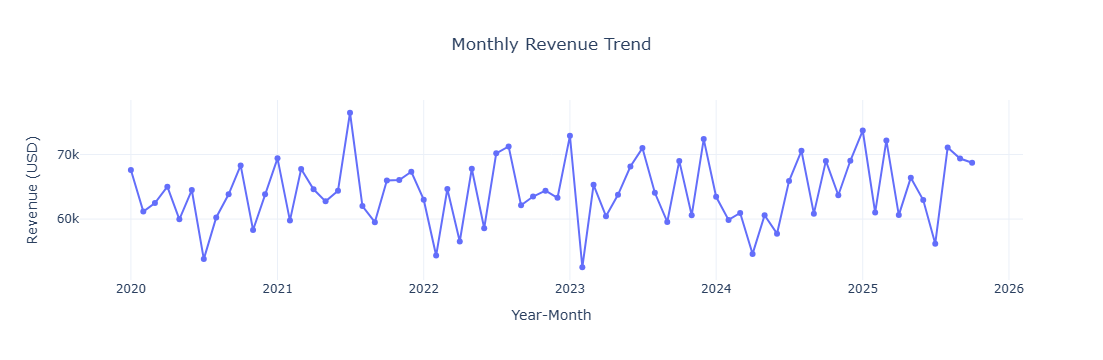

In [1278]:
fig = px.line(
    revenue_trend,
    x="year_month",
    y="total_usd",
    title="Monthly Revenue Trend",
    markers=True
)

fig.update_layout(
    title_x=0.5,
    xaxis_title="Year-Month",
    yaxis_title="Revenue (USD)",
    template="plotly_white"
)

fig.show()

#### Insight: Monthly revenue fluctuated throughout the analysis period, indicating variations in customer purchasing patterns across different months.

## 12.2 Revenue by Product Category

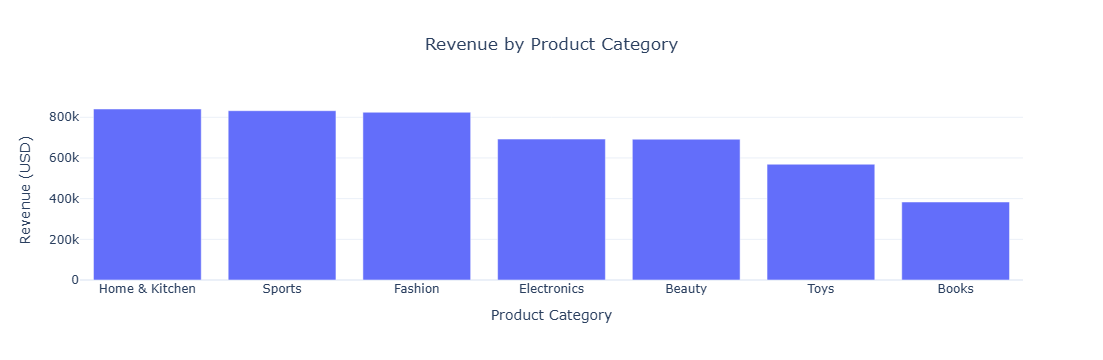

In [1332]:

fig = px.bar(
    category_revenue,
    x="category",
    y="line_total_usd",
    title="Revenue by Product Category"
)

fig.update_layout(
    title_x=0.5,
    xaxis_title="Product Category",
    yaxis_title="Revenue (USD)",
    template="plotly_white"
)

fig.show()

#### Insight: Home & Kitchen generated the highest revenue, followed by Sports and Fashion, highlighting these as the top-performing product categories.

## 12.3 Top 10 Products by Revenue

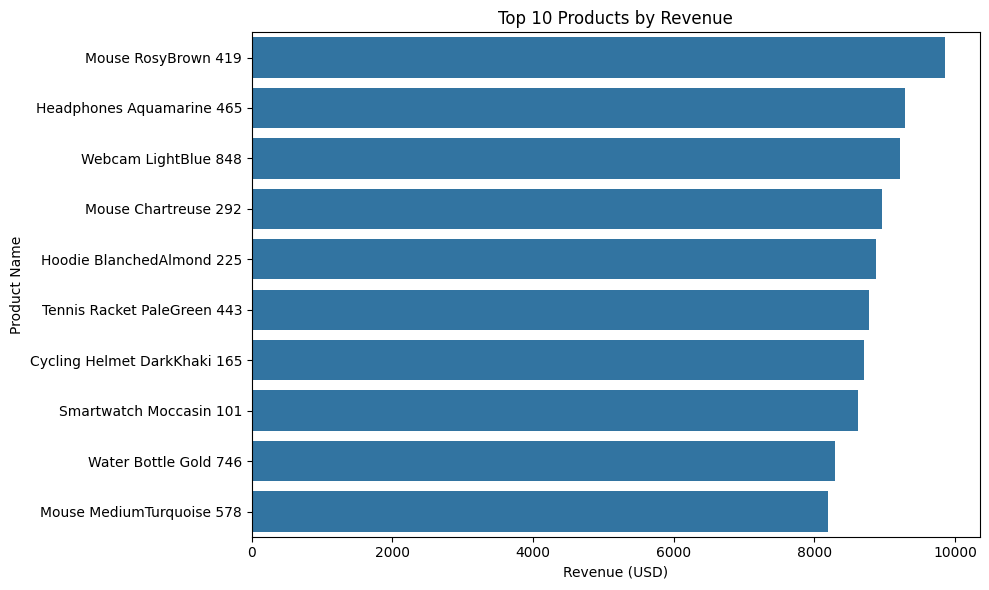

In [1330]:

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_products,
    x="line_total_usd",
    y="name"
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (USD)")
plt.ylabel("Product Name")

plt.tight_layout()
plt.show()

#### Insight: The top 10 products contributed a significant share of total revenue, with Mouse RosyBrown 419 emerging as the highest-revenue product.

## 12.4 Event Distribution

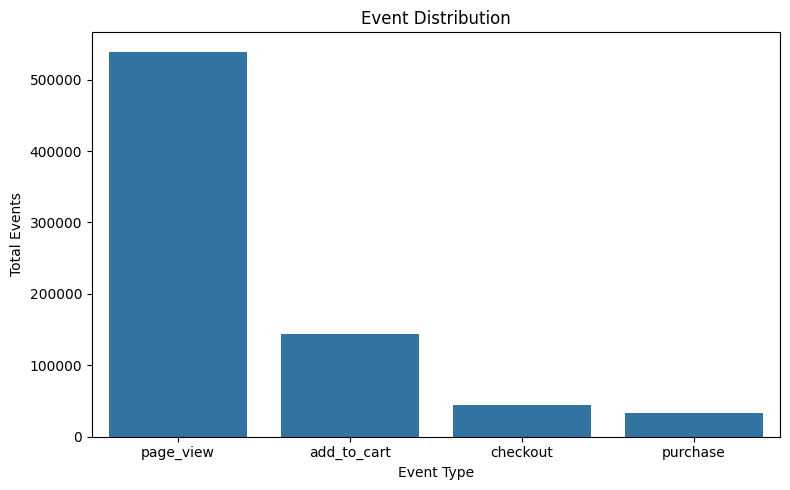

In [1325]:

plt.figure(figsize=(8,5))

sns.barplot(
    data=event_distribution,
    x="event_type",
    y="Total_events"
)

plt.title("Event Distribution")
plt.xlabel("Event Type")
plt.ylabel("Total Events")

plt.tight_layout()
plt.show()

#### Insight: Page View was the most frequent customer event, while the number of events gradually decreased through Add to Cart, Checkout, and Purchase, reflecting the customer conversion funnel.

## 12.5 Revenue by Payment Method

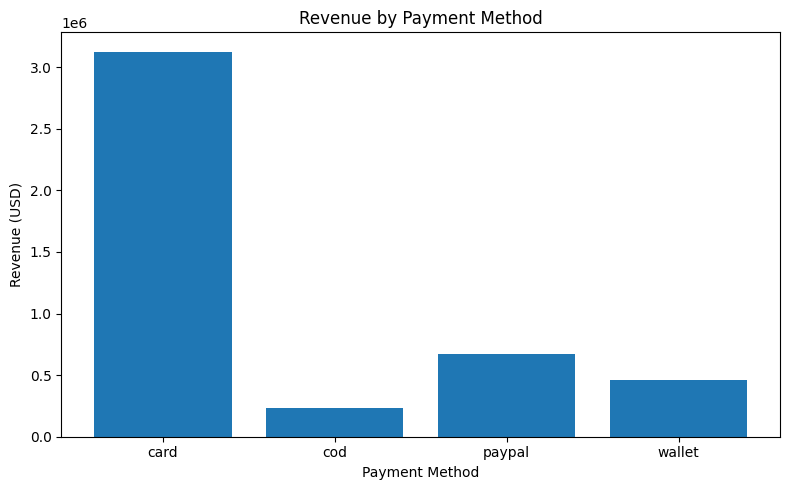

In [1327]:

plt.figure(figsize=(8,5))

plt.bar(
    revenue_by_payment["payment_method"],
    revenue_by_payment["total_usd"]
)

plt.title("Revenue by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Revenue (USD)")

plt.tight_layout()
plt.show()

#### Insight: Card payments generated the highest revenue, followed by PayPal, Wallet, and Cash on Delivery (COD).